[Reference](https://medium.com/@piyushagni5/human-in-the-loop-with-langgraph-mastering-interrupts-and-commands-9e1cf2183ae3)

# Method 1: Runtime Interrupts Using interrupt() Function


In [2]:
!pip install langgraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.7/216.7 kB 16.7 MB/s eta 0:00:00


## Step 1: Import Required Libraries

In [3]:
from typing import TypedDict
import uuid
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.constants import START
from langgraph.graph import StateGraph
from langgraph.types import interrupt, Command

## Step 2: Define the State Schema

In [4]:
class State(TypedDict):
    some_text: str

## Step 3: Create the Human Node Function

In [5]:
def human_node(state: State):
    print(f"Node started with state: {state}")
    # Present current state to human and pause execution
    value = interrupt({
        "text_to_revise": state["some_text"]
    })
    print(f"Received human input: {value}")
    # When resumed, this will contain the human's input
    return {
        "some_text": value
    }

## Step 4: Build the Graph Structure

In [6]:
graph_builder = StateGraph(State)
graph_builder.add_node("human_node", human_node)
graph_builder.add_edge(START, "human_node")

## Step 5: Add Checkpointing and Compile


In [7]:
checkpointer = InMemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer)

## Step 6: Visualize the Graph


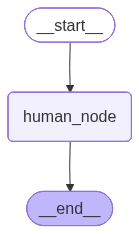

In [8]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod
display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

## Step 7: Initialize Execution

In [9]:
config = {"configurable": {"thread_id": uuid.uuid4()}}
print("🚀 Starting graph execution...")
result = graph.invoke({"some_text": "original text"}, config=config)

🚀 Starting graph execution...
Node started with state: {'some_text': 'original text'}


In [10]:
print("Graph paused! Here's what happened:")
print(f"Current state: {result}")
print(f"Interrupt details: {result.get('__interrupt__')}")

Graph paused! Here's what happened:
Current state: {'some_text': 'original text', '__interrupt__': [Interrupt(value={'text_to_revise': 'original text'}, id='8d27c56d0938563acba023bf1b30f424')]}
Interrupt details: [Interrupt(value={'text_to_revise': 'original text'}, id='8d27c56d0938563acba023bf1b30f424')]


## Step 8: Inspect Current State


In [11]:
# Check the current state
current_state = graph.get_state(config)
print(f"Current graph state: {current_state.values}")
print(f"Next node to execute: {current_state.next}")

Current graph state: {'some_text': 'original text'}
Next node to execute: ('human_node',)


## Step 9: Resume Execution

In [12]:
print("\n Resuming with human input...")
final_result = graph.invoke(Command(resume="Edited text"), config=config)
print(f" Final result: {final_result}")


 Resuming with human input...
Node started with state: {'some_text': 'original text'}
Received human input: Edited text
 Final result: {'some_text': 'Edited text'}


# Method 2: Interrupts Using interrupt_before and interrupt_after


In [13]:
from typing import TypedDict
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command
import uuid

class SimpleState(TypedDict):
    message: str
    processed: bool

def processing_node(state: SimpleState):
    print(f"Processing node received: {state}")
    return {
        "message": f"Processed: {state['message']}",
        "processed": True
    }

def final_node(state: SimpleState):
    print(f"Final node received: {state}")
    return {
        "message": f"Final: {state['message']}",
        "processed": True
    }

# Build graph
graph_builder = StateGraph(SimpleState)
graph_builder.add_node("processing_node", processing_node)
graph_builder.add_node("final_node", final_node)
graph_builder.add_edge(START, "processing_node")
graph_builder.add_edge("processing_node", "final_node")

In [14]:
# Example 1: interrupt_before

graph_before = graph_builder.compile(
    checkpointer=InMemorySaver(),
    interrupt_before=["processing_node"]
)

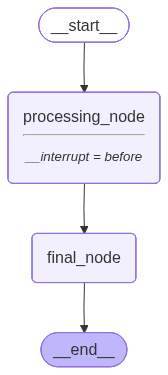

In [15]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph_before.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [16]:
config = {"configurable": {"thread_id": str(uuid.uuid4())}}

# Starting execution
result = graph_before.invoke({"message": "Hello", "processed": False}, config=config)
print(result)

{'message': 'Hello', 'processed': False}


In [17]:
state = graph_before.get_state(config)
print(f"Graph state: {state.values}")
print(f"Next node: {state.next}")

Graph state: {'message': 'Hello', 'processed': False}
Next node: ('processing_node',)


In [18]:
final_result = graph_before.invoke(None, config=config)
print(f" Final result: {final_result}")

Processing node received: {'message': 'Hello', 'processed': False}
Final node received: {'message': 'Processed: Hello', 'processed': True}
 Final result: {'message': 'Final: Processed: Hello', 'processed': True}


In [19]:
### Testing interrupt_after
graph_after = graph_builder.compile(
    checkpointer=InMemorySaver(),
    interrupt_after=["processing_node"]
)

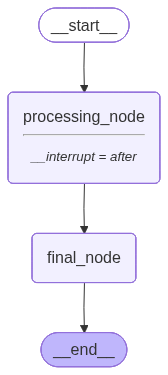

In [20]:
display(
    Image(
        graph_after.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [21]:
config = {"configurable": {"thread_id": str(uuid.uuid4())}}
# print(" Starting execution with stream...")

# Initial execution
for chunk in graph_after.stream({"message": "Stream test", "processed": False}, config=config):
    print(f"Chunk: {chunk}")

Processing node received: {'message': 'Stream test', 'processed': False}
Chunk: {'processing_node': {'message': 'Processed: Stream test', 'processed': True}}
Chunk: {'__interrupt__': ()}


In [22]:
print("Interrupted before final_node!")
state = graph_after.get_state(config)
print(f"Graph state: {state.values}")
print(f"Next node: {state.next}")

Interrupted before final_node!
Graph state: {'message': 'Processed: Stream test', 'processed': True}
Next node: ('final_node',)


In [24]:
# Resume execution
for chunk in graph_after.stream(None, config=config):
    print(f"Resume chunk: {chunk}")

Final node received: {'message': 'Processed: Stream test', 'processed': True}
Resume chunk: {'final_node': {'message': 'Final: Processed: Stream test', 'processed': True}}
